In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

# 모델 성능 평가: Precision, Recall, F1 Score, ROC Curve, AUC
from sklearn.metrics import precision_score, recall_score, f1_score, roc_curve, auc, accuracy_score
from sklearn.metrics import confusion_matrix, classification_report

# 실행결과 경고메시지 출력 제외
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("../B1_data/preprocessing_data/final_data.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14816 entries, 0 to 14815
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   type               14816 non-null  object 
 1   Temp_OXid          14816 non-null  float64
 2   ppm                14816 non-null  float64
 3   Pressure           14816 non-null  float64
 4   Oxid_time          14816 non-null  int64  
 5   N2_HMDS            14816 non-null  float64
 6   pressure_HMDS      14816 non-null  float64
 7   temp_HMDS          14816 non-null  float64
 8   time_HMDS_bake     14816 non-null  float64
 9   spin1              14816 non-null  float64
 10  spin2              14816 non-null  float64
 11  spin3              14816 non-null  float64
 12  photoresist_bake   14816 non-null  float64
 13  temp_softbake      14816 non-null  float64
 14  time_softbake      14816 non-null  float64
 15  kperna             14816 non-null  float64
 16  Energy_Exposure    148

In [3]:
df.drop(['etching_velo','kperna'], inplace = True, axis = 1)

In [4]:
object_x = df.select_dtypes('object')
numeric_x = df.select_dtypes(exclude = 'object')
numeric_x.drop('y_label', axis = 1, inplace = True)

In [51]:
dummies = pd.get_dummies(object_x)

std = StandardScaler()
scaled_df = std.fit_transform(numeric_x)
scaled_df = pd.DataFrame(scaled_df, columns = numeric_x.columns)

df_scale_dummies_x = pd.concat([scaled_df, dummies], axis = 1)
df_scale_dummies_x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14816 entries, 0 to 14815
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Temp_OXid          14816 non-null  float64
 1   ppm                14816 non-null  float64
 2   Pressure           14816 non-null  float64
 3   Oxid_time          14816 non-null  float64
 4   N2_HMDS            14816 non-null  float64
 5   pressure_HMDS      14816 non-null  float64
 6   temp_HMDS          14816 non-null  float64
 7   time_HMDS_bake     14816 non-null  float64
 8   spin1              14816 non-null  float64
 9   spin2              14816 non-null  float64
 10  spin3              14816 non-null  float64
 11  photoresist_bake   14816 non-null  float64
 12  temp_softbake      14816 non-null  float64
 13  time_softbake      14816 non-null  float64
 14  Energy_Exposure    14816 non-null  float64
 15  Source_Power       14816 non-null  float64
 16  Temp_Etching       148

In [6]:
df_y = df['y_label']
df_y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 14816 entries, 0 to 14815
Series name: y_label
Non-Null Count  Dtype
--------------  -----
14816 non-null  int64
dtypes: int64(1)
memory usage: 115.9 KB


In [7]:
train_x, test_x,  train_y, test_y = train_test_split(df_scale_dummies_x, df_y, test_size = 0.3, random_state=1986)

In [8]:
train_x.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 10371 entries, 7583 to 4128
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Temp_OXid          10371 non-null  float64
 1   ppm                10371 non-null  float64
 2   Pressure           10371 non-null  float64
 3   Oxid_time          10371 non-null  float64
 4   N2_HMDS            10371 non-null  float64
 5   pressure_HMDS      10371 non-null  float64
 6   temp_HMDS          10371 non-null  float64
 7   time_HMDS_bake     10371 non-null  float64
 8   spin1              10371 non-null  float64
 9   spin2              10371 non-null  float64
 10  spin3              10371 non-null  float64
 11  photoresist_bake   10371 non-null  float64
 12  temp_softbake      10371 non-null  float64
 13  time_softbake      10371 non-null  float64
 14  Energy_Exposure    10371 non-null  float64
 15  Source_Power       10371 non-null  float64
 16  Temp_Etching       1

In [43]:

param = {
    'hidden_layer_sizes' : [(24,),(28,),(32,)],
    'activation' : ['tanh'],
    'batch_size' : [32,64,128,256],
    'learning_rate_init' : [0.001, 0.005, 0.01]
}

grid_search = GridSearchCV(MLPClassifier(max_iter=500, random_state=42, solver='adam', early_stopping=True, verbose= 2), # max_iter 증가, early_stopping 추가
                           param_grid = param, verbose=10, n_jobs=2) # verbose 증가, n_jobs 변경
grid_search.fit(train_x, train_y)

print(grid_search.best_params_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Iteration 1, loss = 0.27397664
Validation score: 0.939306
Iteration 2, loss = 0.20971812
Validation score: 0.943160
Iteration 3, loss = 0.19077184
Validation score: 0.946050
Iteration 4, loss = 0.17298479
Validation score: 0.946050
Iteration 5, loss = 0.15247815
Validation score: 0.948940
Iteration 6, loss = 0.13390837
Validation score: 0.952794
Iteration 7, loss = 0.11758048
Validation score: 0.954721
Iteration 8, loss = 0.10426149
Validation score: 0.964355
Iteration 9, loss = 0.09283075
Validation score: 0.961464
Iteration 10, loss = 0.08330751
Validation score: 0.968208
Iteration 11, loss = 0.07672937
Validation score: 0.967245
Iteration 12, loss = 0.06897698
Validation score: 0.973025
Iteration 13, loss = 0.06400120
Validation score: 0.977842
Iteration 14, loss = 0.06001328
Validation score: 0.973025
Iteration 15, loss = 0.05697000
Validation score: 0.979769
Iteration 16, loss = 0.05299914
Validation score: 0.977842
Ite

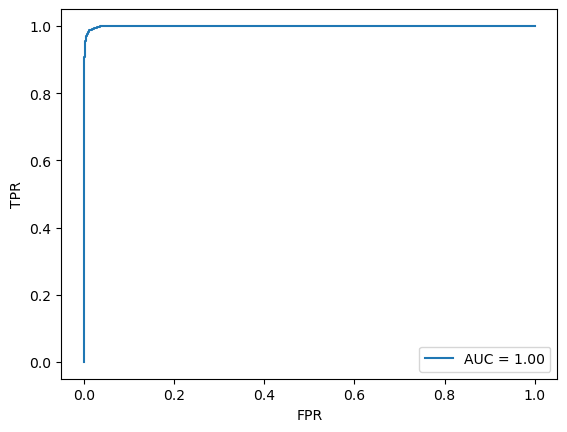

[[9591   20]
 [  47  713]]


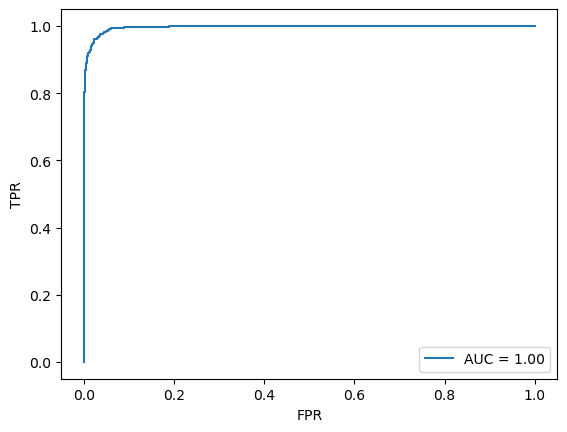

[[4115   15]
 [  41  274]]
             NN_train   NN_test
Accuracy     0.993540  0.987402
Precision    0.972715  0.948097
Recall       0.938158  0.869841
F1_score     0.955124  0.907285
Specificity  0.997919  0.996368


In [47]:
def print_metric(y_true, y_pred, y_pred_proba, data_name): # 실제값, 예측값, ROC 커브이미지 저장이름 ex)RF-train
    cm = confusion_matrix(y_true, y_pred)
    TP = cm[1][1]
    TN = cm[0][0]
    FP = cm[0][1]
    FN = cm[1][0]

    accuracy = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP)
    recall = TP / (TP + FN)
    f1_score = 2 * (precision * recall) / (precision + recall)
    specificity = TN / (TN + FP)

    metric_list = [accuracy, precision,recall, f1_score, specificity]
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label= "AUC = %0.2f"% roc_auc)
    plt.legend(loc="lower right")
    plt.ylabel("TPR"); plt.xlabel("FPR")
    #plt.savefig(data_name+"_roc_curve.png")
    plt.show()
    print(cm)
    return pd.DataFrame(metric_list, index=['Accuracy', 'Precision', 'Recall', 'F1_score', 'Specificity'])

best_model = grid_search.best_estimator_
y_pred_train = best_model.predict(train_x)
y_proba_train = best_model.predict_proba(train_x)[:, 1]
y_pred_test = best_model.predict(test_x)
y_proba_test = best_model.predict_proba(test_x)[:, 1]


metric_df_first = pd.DataFrame()
metric_list_train = print_metric(train_y, y_pred_train,y_proba_train, "NN_train")
metric_list_test = print_metric(test_y, y_pred_test, y_proba_test, "NN_test")

metric_df_first['NN_train'] = metric_list_train
metric_df_first['NN_test'] = metric_list_test

print(metric_df_first)

# pilot test

In [39]:
import joblib  

# 모델 저장
#joblib.dump(best_model, "[B1]best_model(nn).pkl")

# 모델 불러오기
best_model = joblib.load("[B1]best_model(nn).pkl")


best_model

MLPClassifier(activation='tanh', batch_size=64, early_stopping=True,
              hidden_layer_sizes=(28,), learning_rate_init=0.005, max_iter=500,
              random_state=42, verbose=2)

In [58]:
pilot_data = pd.read_csv("../B1_data/이게_진짜로_새로운_유의성.csv")
x_pilot = pilot_data.drop(['y_label','type_wet','type_dry'], axis = 1)
y_pilot = pilot_data['y_label']
scaled_pilot = std.transform(x_pilot)
scaled_pilot = pd.DataFrame(scaled_pilot, columns = x_pilot.columns)
scaled_pilot['type_wet'], scaled_pilot['type_dry'] = pilot_data['type_wet'], pilot_data['type_dry']
scaled_pilot = scaled_pilot[pilot_data.drop('y_label', axis = 1).columns]
y_pred_pilot = best_model.predict(scaled_pilot)

In [59]:
print(np.unique(y_pred_pilot, return_counts=True))
print(np.unique(y_pilot, return_counts = True))

(array([0, 1], dtype=int64), array([14539,   277], dtype=int64))
(array([0, 1], dtype=int64), array([13741,  1075], dtype=int64))


In [61]:
pilot_data_test = pd.read_csv("../B1_data/진짜로_새로운_유의성.csv")

x_pilot = pilot_data_test.drop(['y_label','type_wet','type_dry'], axis = 1)
y_pilot = pilot_data_test['y_label']
scaled_pilot = std.transform(x_pilot)
scaled_pilot = pd.DataFrame(scaled_pilot, columns = x_pilot.columns)
scaled_pilot['type_wet'], scaled_pilot['type_dry'] = pilot_data['type_wet'], pilot_data['type_dry']
scaled_pilot = scaled_pilot[pilot_data.drop('y_label', axis = 1).columns]
y_pred_pilot = best_model.predict(scaled_pilot)

print(np.unique(y_pred_pilot, return_counts=True))
print(np.unique(test_y, return_counts = True))

(array([0, 1], dtype=int64), array([4343,  102], dtype=int64))
(array([0, 1], dtype=int64), array([4130,  315], dtype=int64))


In [62]:
pilot_data_test = pd.read_csv("../B1_data/찐_이게_진짜로_새로운_유의성.csv")

x_pilot = pilot_data_test.drop(['y_label','type_wet','type_dry'], axis = 1)
y_pilot = pilot_data_test['y_label']
scaled_pilot = std.transform(x_pilot)
scaled_pilot = pd.DataFrame(scaled_pilot, columns = x_pilot.columns)
scaled_pilot['type_wet'], scaled_pilot['type_dry'] = pilot_data['type_wet'], pilot_data['type_dry']
scaled_pilot = scaled_pilot[pilot_data.drop('y_label', axis = 1).columns]
y_pred_pilot = best_model.predict(scaled_pilot)

print(np.unique(y_pred_pilot, return_counts=True))
print(np.unique(y_pilot, return_counts = True))

(array([0, 1], dtype=int64), array([14231,   585], dtype=int64))
(array([0, 1], dtype=int64), array([13741,  1075], dtype=int64))
